## Análise exploratória de Dados
Título da pesquisa: Predição de Acidentes em Rodovias Federais de Santa Catarina por Meio de Séries Temporais e Aprendizado de Máquina.

Apesar da PRF disponibilizar dados desde 2007, para nossa análise consideraremos os dados de 2022 a 2026, visto que ao longo dos anos as rodovias sofreram muitas mudanças e também que em 2020 e 2021 a pandemia impactou na quantidade de veículos nas rodovias, alterando padrões de acidentes.

Perguntas importantes para o processo: 
1. O que estamos tentando prever/resolver? 
2. Que tipo de dados temos e como trataremos cada um deles?
3. Há missing values? Se sim, como trataremos? 
4. Temos outliers? 
5. Quais features podemos fazer para extrair mais dos dados? 

## Importações e Carregamento de dados

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import glob

In [ ]:
# Carrega tabelas, filtra por somente acidentes em que uf == "SC" e concatena todas em uma para manipulação facilitada

caminho_ficheiros = '../data/raw/datatran*.csv'
lista_ficheiros = sorted(glob.glob(caminho_ficheiros))

dfs = []

for ficheiro in lista_ficheiros:
    # Lê o CSV ajustando separador e codificação típicos da PRF
    df_temp = pd.read_csv(
        ficheiro, sep=';', encoding='latin1', low_memory=False
    )

    # Filtra por UF == 'SC' logo na leitura para economizar memória
    if 'uf' in df_temp.columns:
        df_temp = df_temp[
            df_temp['uf'].astype(str).str.strip().str.upper() == 'SC'
        ]

    dfs.append(df_temp)

# Concatena todas as tabelas numa só
acidentes_SC = pd.concat(dfs, ignore_index=True)

## Tipagem e estatísticas de colunas

In [ ]:
# .info() nos dá nome e tipo dos dados das colunas da tabela
acidentes_SC.info()

<class 'pandas.DataFrame'>
RangeIndex: 35497 entries, 0 to 35496
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      35497 non-null  float64
 1   data_inversa            35497 non-null  str    
 2   dia_semana              35497 non-null  str    
 3   horario                 35497 non-null  str    
 4   uf                      35497 non-null  str    
 5   br                      35497 non-null  int64  
 6   km                      35497 non-null  str    
 7   municipio               35497 non-null  str    
 8   causa_acidente          35497 non-null  str    
 9   tipo_acidente           35497 non-null  str    
 10  classificacao_acidente  35497 non-null  str    
 11  fase_dia                35497 non-null  str    
 12  sentido_via             35497 non-null  str    
 13  condicao_metereologica  35497 non-null  str    
 14  tipo_pista              35497 non-null  str    
 

In [34]:
# .describe() fornece informações de média, desvio padrão, valor min e max e quartis de colunas númericas
acidentes_SC.describe()

,id,br,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos
count,35497.000000,35497.000000,35497.000000,35497.000000,35497.000000,35497.000000,35497.000000,35497.000000,35497.000000,35497.000000
mean,596790.073105,204.275573,2.469504,0.048737,0.871116,0.259149,1.037581,0.266248,1.130265,1.975716
std,104197.371283,133.618185,1.639151,0.249051,0.884395,0.565396,1.333923,0.599439,0.932680,0.963982
min,405165.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,509257.000000,101.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,594669.000000,101.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000
75%,691218.000000,282.000000,3.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2.000000
max,778425.000000,480.000000,51.000000,5.000000,37.000000,18.000000,49.000000,12.000000,38.000000,31.000000


## Gráficos
Analisando quais cidades, brs tem quantidade maior de acidentes

In [33]:
ranking_br = acidentes_SC['br'].value_counts().reset_index()
ranking_br.columns = ['BR', 'Total_Acidentes']

print("Ranking de BRs com maior número de acidentes entre 2022 e 2026:")
print(ranking_br.head(5))

Ranking de BRs com maior número de acidentes entre 2022 e 2026:
    BR  Total_Acidentes
0  101            18368
1  282             5818
2  470             4917
3  280             3424
4  116             1512


In [35]:
ranking_br = acidentes_SC['municipio'].value_counts().reset_index()
ranking_br.columns = ['Municipio', 'Total_Acidentes']

print("Ranking de Cidades com maior número de acidentes entre 2022 e 2026:")
print(ranking_br.head(5))

Ranking de Cidades com maior número de acidentes entre 2022 e 2026:
            Municipio  Total_Acidentes
0            SAO JOSE             3262
1             PALHOCA             2483
2              ITAJAI             1681
3  BALNEARIO CAMBORIU             1384
4            ARAQUARI             1316


--- Top 15 Causas de Acidentes em SC ---
                                       causa_acidente  total_acidentes
0            Reação tardia ou ineficiente do condutor             5187
1                      Ausência de reação do condutor             4555
2   Acessar a via sem observar a presença dos outr...             3804
3   Condutor deixou de manter distância do veículo...             2568
4                    Ingestão de álcool pelo condutor             2541
5                             Velocidade Incompatível             2266
6                         Manobra de mudança de faixa             2261
7            Desrespeitar a preferência no cruzamento             1280
8                              Transitar na contramão             1204
9                Demais falhas mecânicas ou elétricas             1197
10  Trafegar com motocicleta (ou similar) entre as...             1137
11                             Ultrapassagem Indevida              815
12                                  

/var/folders/r8/qb8zf7yj7yv2dnhf6g2dvg_c0000gn/T/ipykernel_70646/3211974465.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


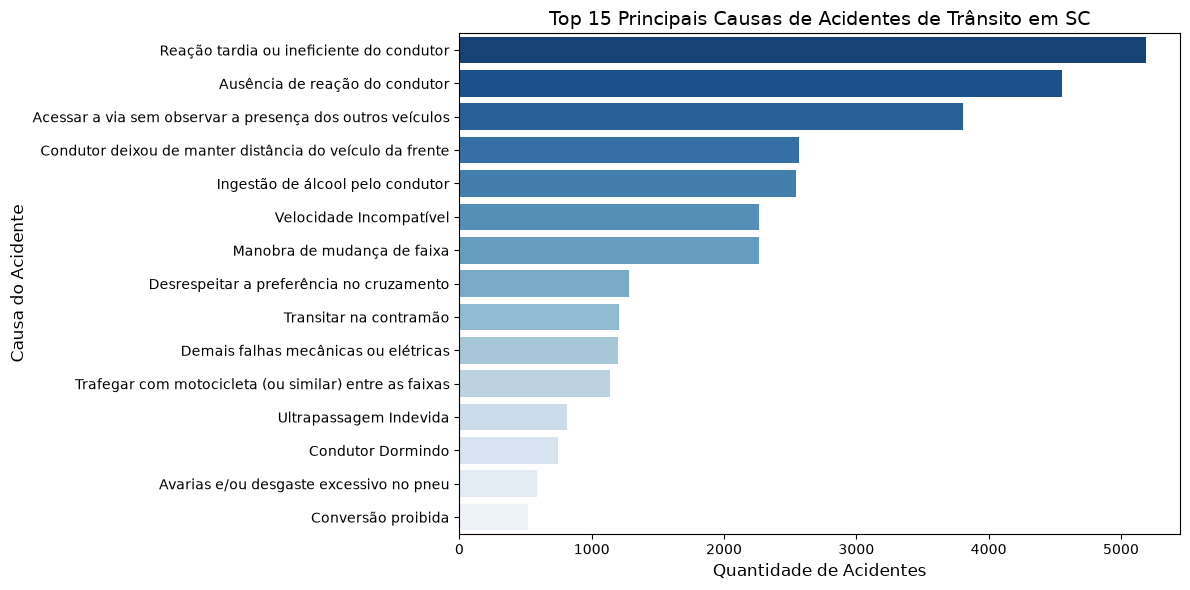

In [36]:
ranking_causas = (
    acidentes_SC['causa_acidente']
    .value_counts()
    .reset_index(name='total_acidentes')
)
ranking_causas.columns = ['causa_acidente', 'total_acidentes']

# Exibe as 15 principais causas na tela
print("--- Top 15 Causas de Acidentes em SC ---")
print(ranking_causas.head(15))

# Plotagem do Gráfico de Barras
plt.figure(figsize=(12, 6))
sns.barplot(
    data=ranking_causas.head(15),
    x='total_acidentes',
    y='causa_acidente',
    palette='Blues_r',
)

plt.title('Top 15 Principais Causas de Acidentes de Trânsito em SC', fontsize=14)
plt.xlabel('Quantidade de Acidentes', fontsize=12)
plt.ylabel('Causa do Acidente', fontsize=12)
plt.tight_layout()

plt.show()

/var/folders/r8/qb8zf7yj7yv2dnhf6g2dvg_c0000gn/T/ipykernel_70646/3085185189.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


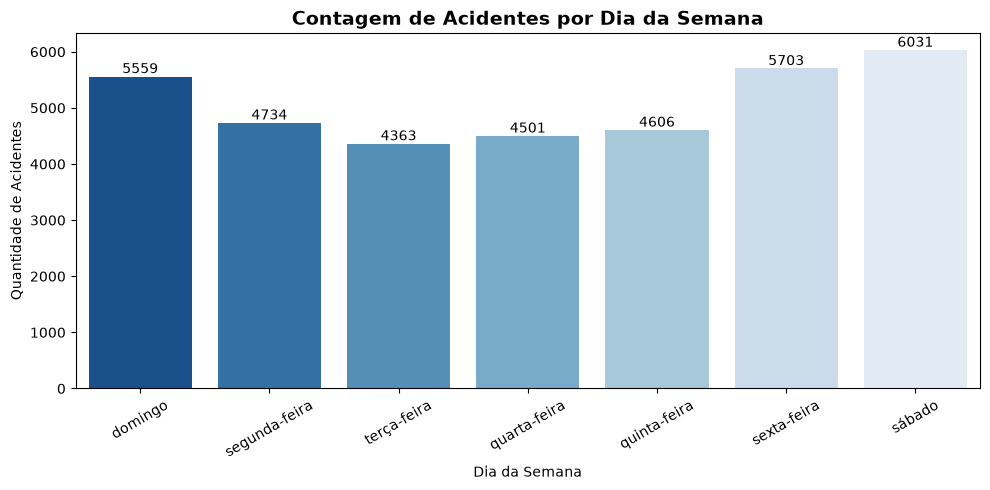

In [45]:
# Contagem de acidentes em cada dia da semana (Gráfico de Barras)
ordem_dias = ['domingo', 'segunda-feira', 'terça-feira', 'quarta-feira', 'quinta-feira', 'sexta-feira', 'sábado']

plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=acidentes_SC, 
    x='dia_semana', 
    order=ordem_dias, 
    palette='Blues_r'
)
plt.title('Contagem de Acidentes por Dia da Semana', fontsize=14, fontweight='bold')
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade de Acidentes')
plt.xticks(rotation=30)
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

/var/folders/r8/qb8zf7yj7yv2dnhf6g2dvg_c0000gn/T/ipykernel_70646/1783949481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


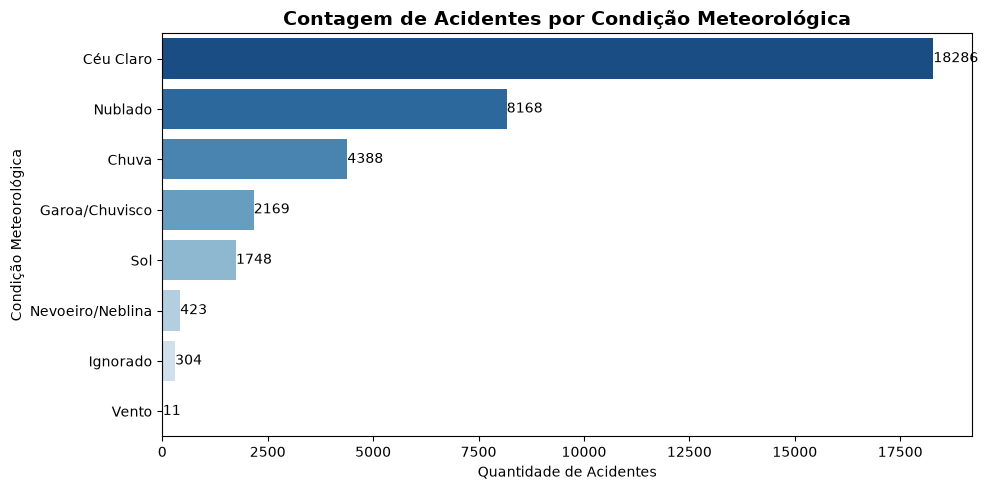

In [47]:
# Contagem de acidentes por condição meteorológica (Gráfico de Barras)

plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=acidentes_SC, 
    y='condicao_metereologica', 
    order=acidentes_SC['condicao_metereologica'].value_counts().index, 
    palette='Blues_r'
)
plt.title('Contagem de Acidentes por Condição Meteorológica', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Acidentes')
plt.ylabel('Condição Meteorológica')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

/var/folders/r8/qb8zf7yj7yv2dnhf6g2dvg_c0000gn/T/ipykernel_70646/524037784.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


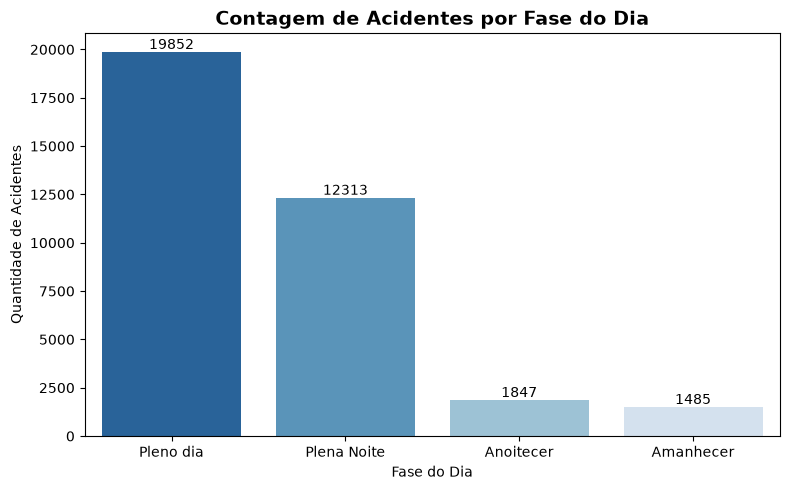

In [48]:
# Contagem de acidentes por fase do dia (Gráfico de Barras)
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=acidentes_SC, 
    x='fase_dia', 
    order=acidentes_SC['fase_dia'].value_counts().index, 
    palette='Blues_r'
)
plt.title('Contagem de Acidentes por Fase do Dia', fontsize=14, fontweight='bold')
plt.xlabel('Fase do Dia')
plt.ylabel('Quantidade de Acidentes')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

/var/folders/r8/qb8zf7yj7yv2dnhf6g2dvg_c0000gn/T/ipykernel_70646/3617903218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


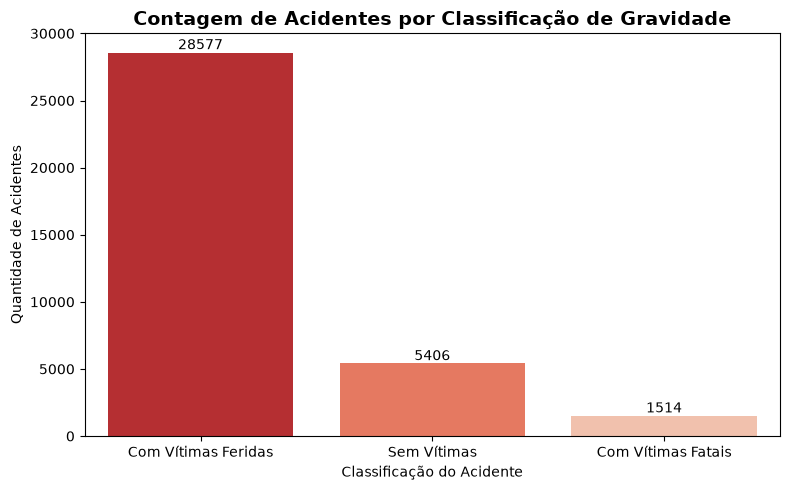

In [49]:
# Contagem de acidentes por classificação do acidente (Gráfico de Barras)
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=acidentes_SC, 
    x='classificacao_acidente', 
    order=acidentes_SC['classificacao_acidente'].value_counts().index, 
    palette='Reds_r'
)
plt.title('Contagem de Acidentes por Classificação de Gravidade', fontsize=14, fontweight='bold')
plt.xlabel('Classificação do Acidente')
plt.ylabel('Quantidade de Acidentes')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

### Adicionar
- Soma de Mortos e Feridos Graves (Comparativo por Ano)
- Quantidade de acidentes por Mês e Ano (Série Temporal / Linhas)

## Insights sobre os dados

Tratamentos necessários:

| Coluna | Descrição |
| --- | --- |
| data_inversa | Transformar para datetime para manipularmos os meses, ano |
